In [1]:
suppressPackageStartupMessages(library(dplyr)) 
library(anndata)
library(ggplot2)
library(pheatmap)
library(RColorBrewer)
library(Seurat)
suppressPackageStartupMessages(library(SeuratExtend))
library(harmony)
library(repr)

source("/projects/ps-renlab2/y2xie/scripts/basics.R")
source("/projects/ps-renlab2/y2xie/scripts/hicat_doubletfinder_mo.R")
source("/projects/ps-renlab2/y2xie/scripts/hicat_vg.R")
source("/projects/ps-renlab2/y2xie/scripts/DPT_help.R")

options(future.globals.maxSize = 64000 * 1024^2) ### default for multiprocess

Warning message:
“package ‘pheatmap’ was built under R version 4.3.2”
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp

Warning message:
“package ‘dichromat’ was built under R version 4.3.2”
Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




In [2]:
### set color
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

cellsubtype_colors <- c(
  NK = "#6A0DAD",                         
  T = "#9B59B6",                          
  Sinusoidal.Endothelial = "#CF1B14",     
  Lymphatic.Endothelial = "#FFCBC2",      
  Central.Vein.Endothelial = "#F27C78",   
  Vascular.Endothelial = "#8E0B0B",       
  Kupffer = "#B04202",                    
  Macrophage = "#F5AD75",                 
  Lipid.Associated.Macrophage = "#FF7105",
  B = "#9E239A",                          
  Plasma = "#E995E7",                     
  Cholangiocyte = "#E1AD01",              
  Quescent.HSC = "#4682B4",               
  Activated.HSC = "#1E90FF",              
  Mesenchymal = "#004F9E",                
  Mast = "#FD7BB8",                       
  Schwann = "#81CDC6",                    
  Hepatocytes.Zone1 = "#006D2C",          
  Hepatocytes.Zone2 = "#4DAF4A",          
  Hepatocytes.Zone3 = "#9ED69F",          
  Hepatocytes.Senescent = "#AED96A",      
  Hepatocytes.Stress = "#526E12"          
)

corder <- c("T", "NK", "B", "Mast", "Myeloid", "Hepatocytes", "Cholangiocyte", "Schwann", 'HSC', "Endothelial")

In [3]:
### Multiome kit barcode mapping
translate <- read.table("/projects/ps-renlab2/y2xie/ps-renlab/y2xie/projects/genome_ref/arc_bc-translation.txt", header = T, row.names = 1, sep = "\t")
translate$atac <- paste0(translate$atac, "-1")
translate$rna <- paste0(translate$rna, "-1")

In [4]:
### quick function
RunRNA2 <- function(obj, reduction = "pca", var = "none", batch.label = "none", k = 15) 
{
    if (var != "none") {
        obj <- SCTransform(obj, vars.to.regress = var, verbose = FALSE)
    }
    else {
        obj <- SCTransform(obj, verbose = FALSE)
    }
    obj <- RunPCA(obj, verbose = F)
    if (batch.label != "none") {
        obj <- RunHarmony(obj, group.by.vars = batch.label)
        reduction <- "harmony"
    }
    obj <- RunUMAP(obj, dims = 1:50, reduction = reduction, 
                   return.model = TRUE, seed.use = 921, metric = "cosine",
                   n.neighbors = k, min.dist = 0.1, n.components = 2L, umap.method = "uwot", 
                   uwot.sgd = TRUE, verbose = F)
    return(obj)
}

## Integrate with Multiome

In [288]:
ref <- qs::qread("../reference/Final_fNIH_Liver_10X_Multiome_RNA.qs")
mmg <- qs::qread("FNIH_DPT_clustering/FNIH_Liver_pool_DPT_SNG_SoupX_reference_mapping_filtered.qs")

ref
mmg

An object of class Seurat 
71583 features across 408178 samples within 3 assays 
Active assay: SCT (34290 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, chromVAR
 4 dimensional reductions calculated: pca, harmony, umap, harmony.rna

An object of class Seurat 
70217 features across 181834 samples within 2 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 5 dimensional reductions calculated: pca, harmony, umap, k27ac_umap, k27me3_umap

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



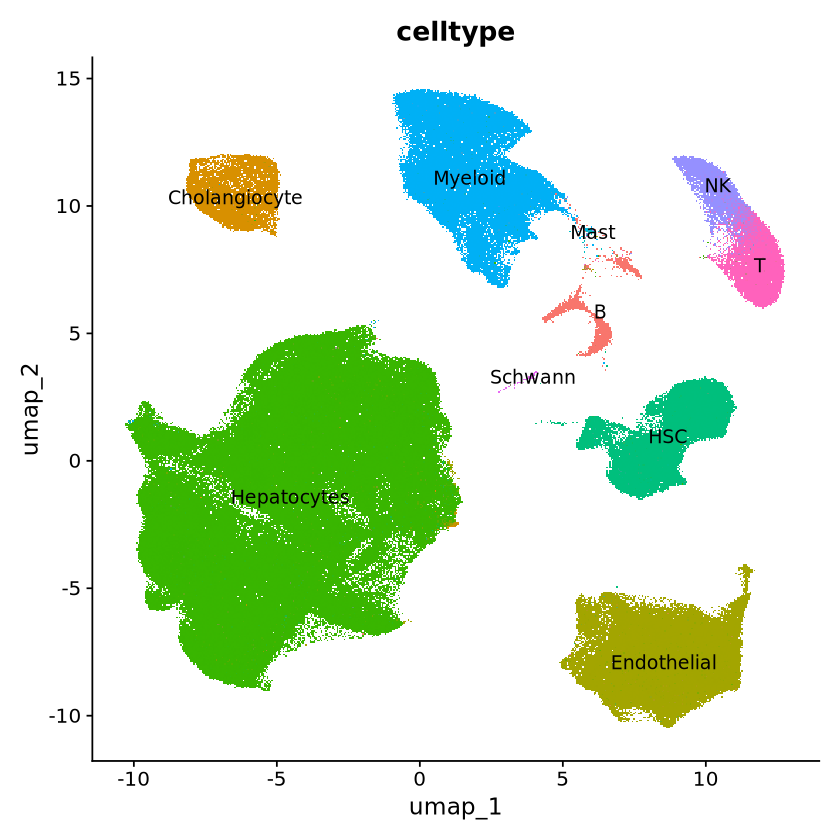

In [68]:
test <- RunUMAP(ref, reduction = "harmony", dims = 1:50, return.model = T, verbose = F, seed.use = 921)
DimPlot(test, reduction = "umap", group.by = "celltype", label = T) + NoLegend()

In [79]:
canchors <- FindTransferAnchors(reference = test, query = mmg, 
                                reference.reduction = "pca", 
                                normalization.method = "SCT")
mpquery2 <- MapQuery(canchors, reference = test, query = mmg,
                     refdata = list(celltype = "celltype", cellsubtype = "cellsubtype"), 
                     reference.reduction = "pca", reduction.model = "umap")
gc()

Normalizing query using reference SCT model

Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 415503 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Predicting cell labels

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data

Computing nearest neighbors

Running UMAP projection

11:39:49 Read 181834 rows

11:39:49 Processing block 1 of 1

11:39:50 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:39:51 Initializing by weighted average of neighbor coordinates using 1 thread

11:39:52 Commencing optimization f

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,12240359,653.8,19111295,1020.7,19111295,1020.7
Vcells,28676079991,218781.2,47896761081,365423.3,47831096565,364922.4


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



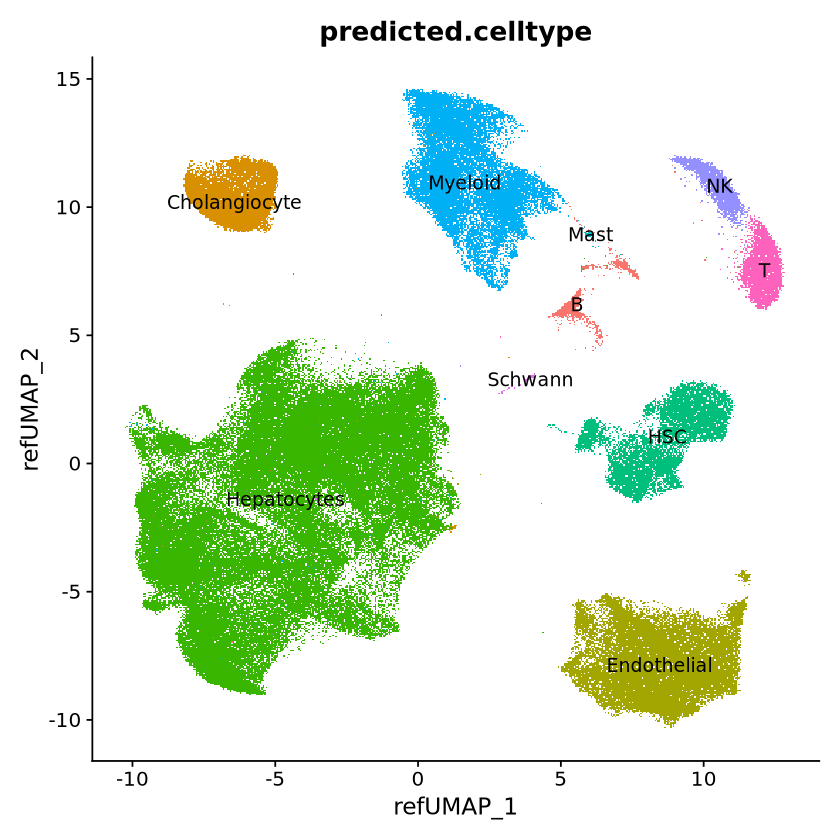

In [80]:
DimPlot(mpquery2, reduction = "ref.umap", group.by = "predicted.celltype", label = T) + NoLegend() 

In [81]:
qs::qsave(mpquery2, "integration/FNIH_Liver_Multiome_DPT_RNA_predicted.qs")
qs::qsave(canchors, "integration/FNIH_Liver_Multiome_DPT_RNA_int.anchors.qs")

In [85]:
rm(list = c("ref", "ref2", "canchors", "test2")); gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,11033286,589.3,19111295,1020.7,19111295,1020.7
Vcells,13992941685,106757.7,38317408865,292338.7,47831096565,364922.4


## Output FNIH files for Hi-C coembedding

In [5]:
library(anndata)
qry <- read_h5ad("../../92.FNIH_DHC_IGM_241121/05.R/integration/FNIH_DHC_genescore.h5ad")
qry <- CreateSeuratObject(t(qry$X), meta.data = qry$obs)
qry

Warning message:
“package ‘anndata’ was built under R version 4.3.1”

Attaching package: ‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers


Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”


An object of class Seurat 
36559 features across 97093 samples within 1 assay 
Active assay: RNA (36559 features, 0 variable features)
 1 layer present: counts

In [16]:
### error fix
qry$log_umi <- log10(qry$nCount_RNA) 

### error fix for subset issue
tmp_SCT_features_attributes = slot(object = ref[['SCT']], name = "SCTModel.list")[[1]]@feature.attributes
tmp_SCT_features_attributes = tmp_SCT_features_attributes[intersect(VariableFeatures(ref), rownames(qry)), ]
slot(object = ref[['SCT']], name = "SCTModel.list")[[1]]@feature.attributes = tmp_SCT_features_attributes

qry <- SCTransform(qry, residual.features = intersect(VariableFeatures(ref), rownames(qry)), 
                   reference.SCT.model = ref@assays$SCT@SCTModel.list$model1) ### regress nCount_RNA has similar effect as regressing unique pairs
qs::qsave(qry, "../../92.FNIH_DHC_IGM_241121/05.R/integration/FNIH_DHC_genescore.qs")

In [20]:
library(SeuratDisk)
system("rm integration/FNIH_Multiome_RNA_int.obj.h5ad integration/FNIH_Multiome_RNA_int.obj.h5Seurat")
mmg <- CreateSeuratObject(ref[["SCT"]]@counts, meta.data = ref@meta.data)
mmg[["RNA"]] <- as(mmg[["RNA"]], "Assay")
mmg[["RNA"]]@scale.data <- ref[["SCT"]]@scale.data
SaveH5Seurat(mmg, filename = "integration/FNIH_Multiome_RNA_int.obj.h5Seurat")
Convert("integration/FNIH_Multiome_RNA_int.obj.h5Seurat", dest = "h5ad")

Warning message:
“No layers found matching search pattern provided”
Warning message:
“No layers found matching search pattern provided”
Warning message:
“No layers found matching search pattern provided”
Warning message:
“Layer ‘data’ is empty”
Warning message:
“No layers found matching search pattern provided”
Warning message:
“No layers found matching search pattern provided”
Warning message:
“Layer ‘scale.data’ is empty”
Warning message:
“Assay RNA changing from Assay5 to Assay”
Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA

Adding data for RNA

Adding scale.data for RNA

No variable features found for RNA

No feature-level metadata found for RNA

Validating h5Seurat file

Adding scale.data from RNA as X

Adding data from RNA as raw

Transfering meta.data to obs



In [640]:
system("mkdir integration/coembed")
pca_loadings <- ref[["pca"]]@feature.loadings
write.csv(pca_loadings, file = "integration/coembed/FNIH_Multiome_RNA_pca_loadings.csv", row.names = TRUE)
pca_embeddings <- Embeddings(ref, "pca")
write.csv(pca_embeddings, file = "integration/coembed/FNIH_Multiome_RNA_pca_embeddings.csv", row.names = TRUE)
write.table(ref@reductions$pca@stdev, "integration/coembed/FNIH_Multiome_RNA_pca_stdev.csv", row.names = F, col.names = F, sep = "\t", quote = F)

## Load joint embedding from Hi-C


FALSE  TRUE 
 4293 92800 

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


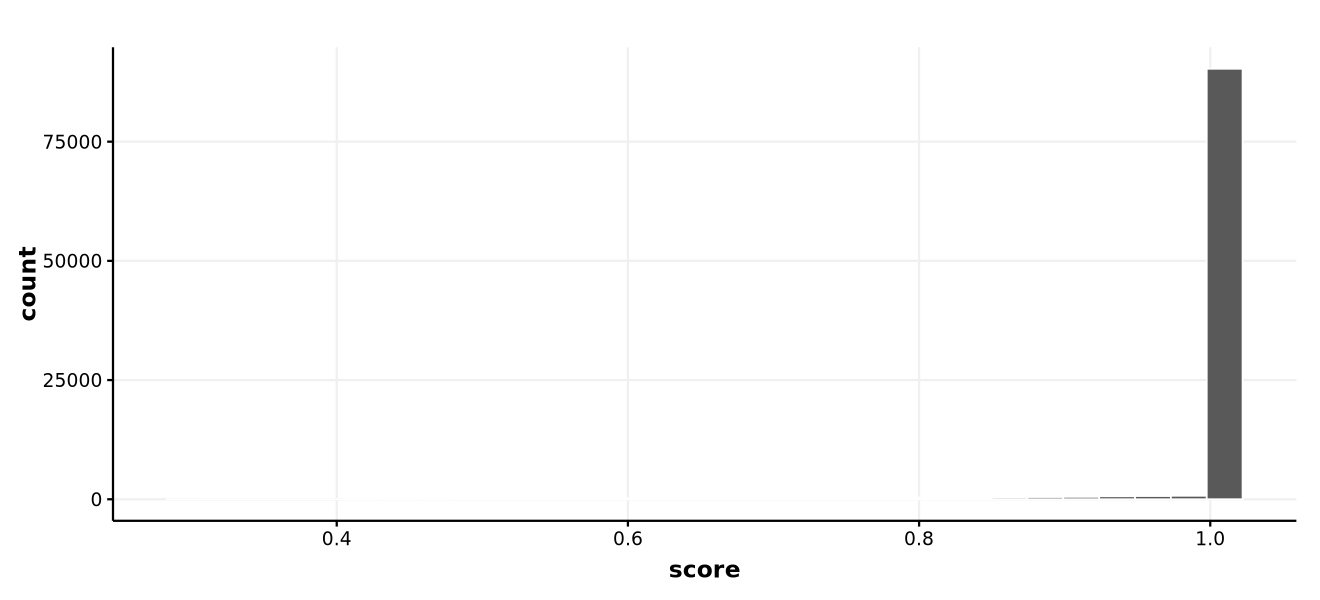

In [90]:
intobj <- read_h5ad("../../92.FNIH_DHC_IGM_241121//05.R/integration/FNIH_DHC_genescore_joint_embedding.h5ad")
pred <- read.csv("../../92.FNIH_DHC_IGM_241121//05.R/integration/FNIH_DHC_genescore_prediction.prediction.csv", header = T, row.names = 1)
table(pred$score >= 0.9)

pred %>%
ggplot(aes(x = score)) + 
geom_histogram(color = "white") + 
theme_Publication()

In [104]:
gene3c <- read_h5ad("../../92.FNIH_DHC_IGM_241121/05.R/integration/FNIH_DHC_genescore.h5ad")
gene3c <- CreateSeuratObject(t(gene3c$X), meta.data = gene3c$obs)

tmp <- (intobj$obsm$cca[(intobj$obs_names %in% colnames(ref)),])
mmg <- CreateSeuratObject(ref[["SCT"]]@counts, meta.data = ref@meta.data)
mmg[["RNA"]] <- as(mmg[["RNA"]], "Assay")
rownames(tmp) <- intobj$obs_names[intobj$obs_names %in% colnames(ref)]
mmg[["cca"]] <- CreateDimReducObject(embeddings = tmp, key = "CCA")
mmg[["umap"]] <- CreateDimReducObject(embeddings = ref[["umap"]]@cell.embeddings, assay = "RNA")
mmg[["umap"]]@misc$model <- ref[["umap"]]@misc$model

tmp <- (intobj$obsm$cca[(intobj$obs_names %in% colnames(gene3c)),])
rownames(tmp) <- intobj$obs_names[intobj$obs_names %in% colnames(gene3c)]
gene3c[["cca"]] <- CreateDimReducObject(embeddings = tmp, key = "CCA")

gene3c <- ProjectUMAP(query = gene3c, query.dims = 1:30, reference = mmg, reference.dims = 1:30, 
                      reference.reduction = 'cca', query.reduction = 'cca', reduction.model = "umap", 
                      k.param = 30, l2.norm = T)

Computing nearest neighbors

Running UMAP projection

10:41:29 Read 97093 rows

10:41:29 Processing block 1 of 1

10:41:29 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:41:30 Initializing by weighted average of neighbor coordinates using 1 thread

10:41:31 Commencing optimization for 67 epochs, with 2912723 positive edges

10:41:42 Finished



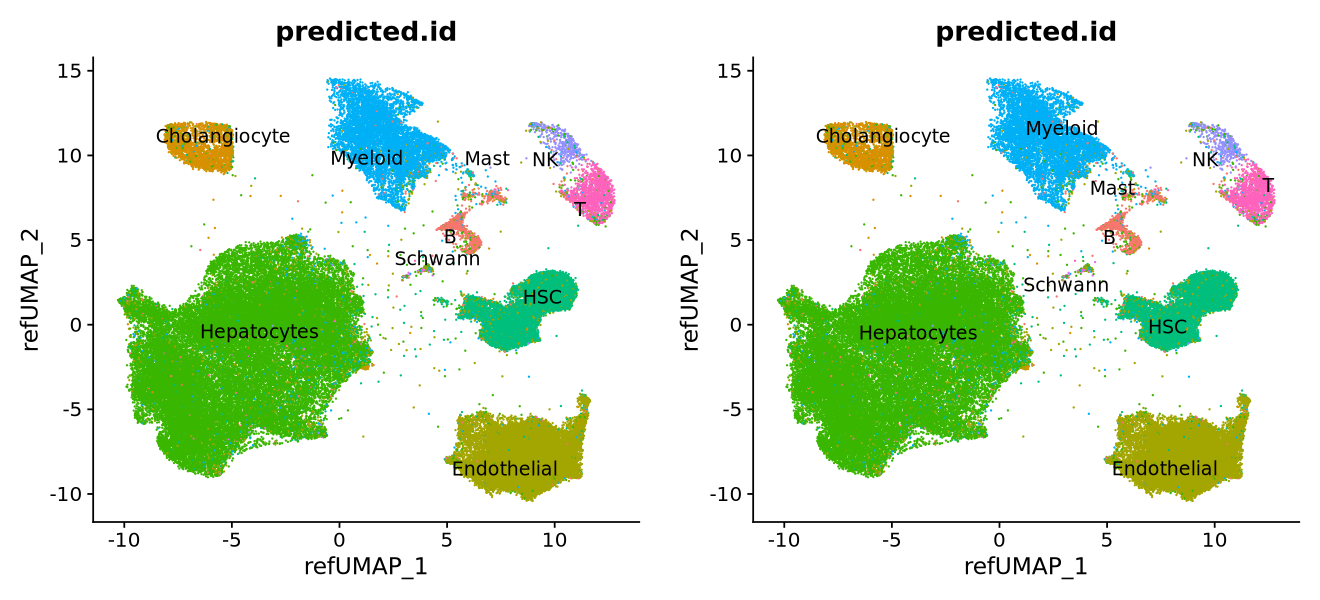

In [105]:
gene3c@meta.data[,c("predicted.id", "predicted.score")] <- pred[colnames(gene3c), c("rnatype", "score")]
t1 <- DimPlot(gene3c, group.by = "predicted.id", label = T, repel = T, reduction = 'ref.umap',
              cells = rownames(gene3c@meta.data[gene3c$predicted.score >= 0.9,])) + NoLegend()
t2 <- DimPlot(gene3c, group.by = "predicted.id", label = T, repel = T, reduction = 'ref.umap', 
              cells = rownames(gene3c@meta.data[gene3c$predicted.score >= 0.9 & gene3c$nCount_RNA >= 500 & gene3c$`cis_1kb+` >= 500,])) + NoLegend()

options(repr.plot.width = 11, repr.plot.height = 5)
cowplot::plot_grid(t1, t2)

In [106]:
qs::qsave(gene3c, "../../92.FNIH_DHC_IGM_241121//05.R/integration/FNIH_DHC_genescore.int.qs")

## Merge all data and inspect label transfer results

In [90]:
ref <- test
mmg <- mpquery2

ref
mmg

An object of class Seurat 
71583 features across 408178 samples within 3 assays 
Active assay: SCT (34290 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, chromVAR
 4 dimensional reductions calculated: pca, harmony, umap, harmony.rna

An object of class Seurat 
70249 features across 181834 samples within 4 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: RNA, prediction.score.celltype, prediction.score.cellsubtype
 7 dimensional reductions calculated: pca, harmony, umap, k27ac_umap, k27me3_umap, ref.pca, ref.umap

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



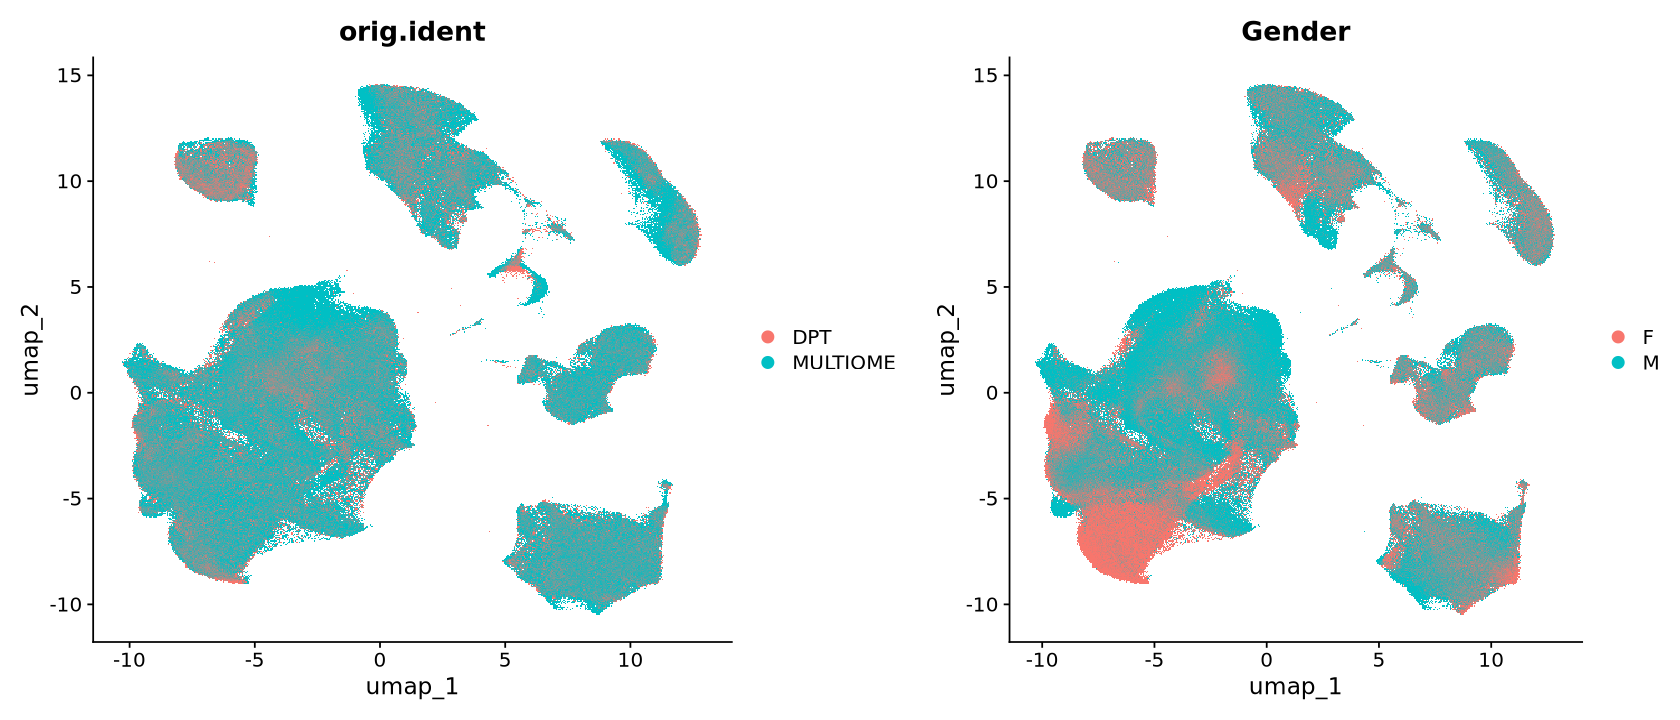

In [93]:
tmp <- rbind(ref@reductions$umap@cell.embeddings,
             mmg@reductions$ref.umap@cell.embeddings)

obj <- merge(ref, mmg, merge.dr = NA)
obj@reductions$joint.umap <- CreateDimReducObject(embeddings = tmp, assay = "SCT")

obj@meta.data[colnames(mmg), ]$orig.ident <- "DPT"
obj@meta.data[colnames(ref), ]$orig.ident <- "MULTIOME"

options(repr.plot.width = 14, repr.plot.height = 6)

t1 <- DimPlot(obj, reduction = "joint.umap", group.by = 'orig.ident')
t2 <- DimPlot(obj, reduction = "joint.umap", group.by = 'Gender')
fig1 <- cowplot::plot_grid(t1, t2, rel_widths = c(1.2, 1))

fig1

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Removed 408178 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 408178 rows containing non-finite outside the scale range (`stat_bin()`).”


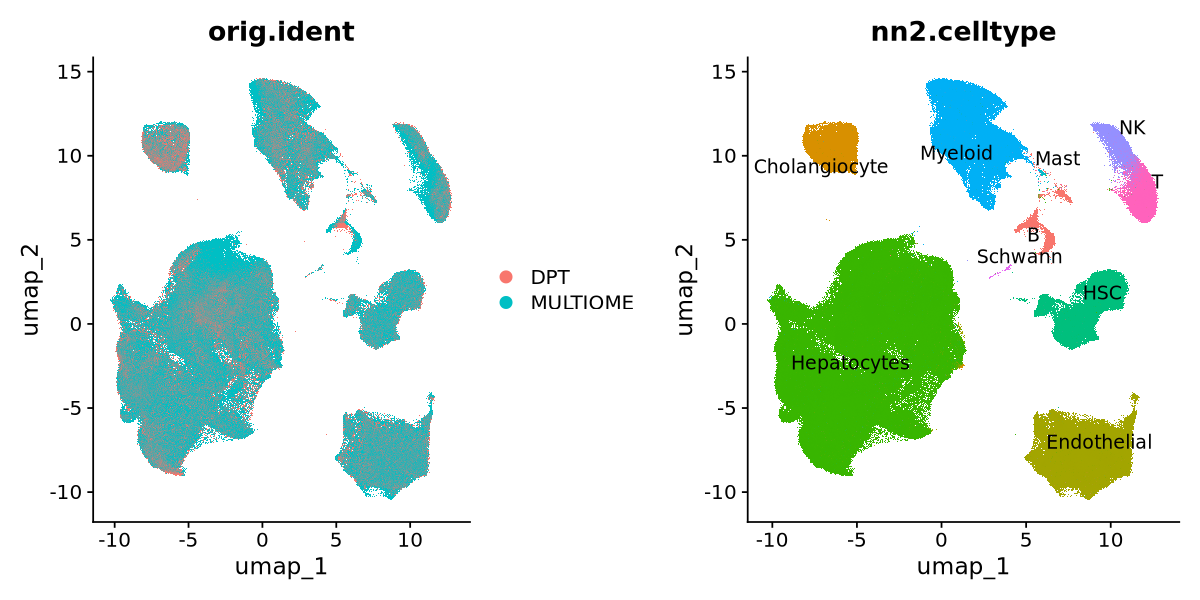

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


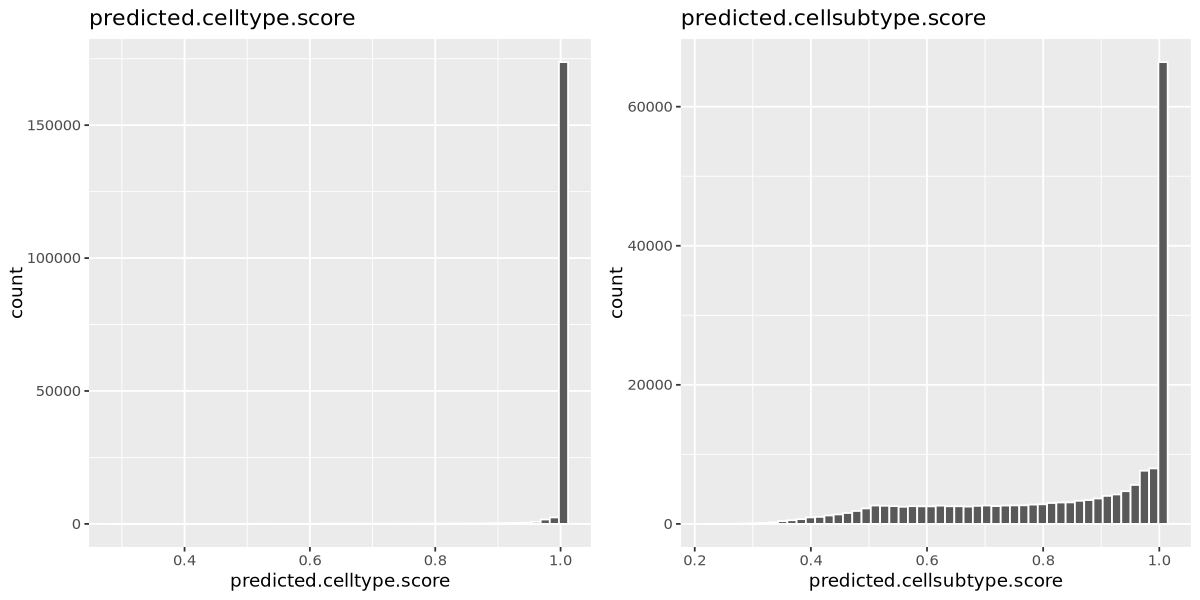

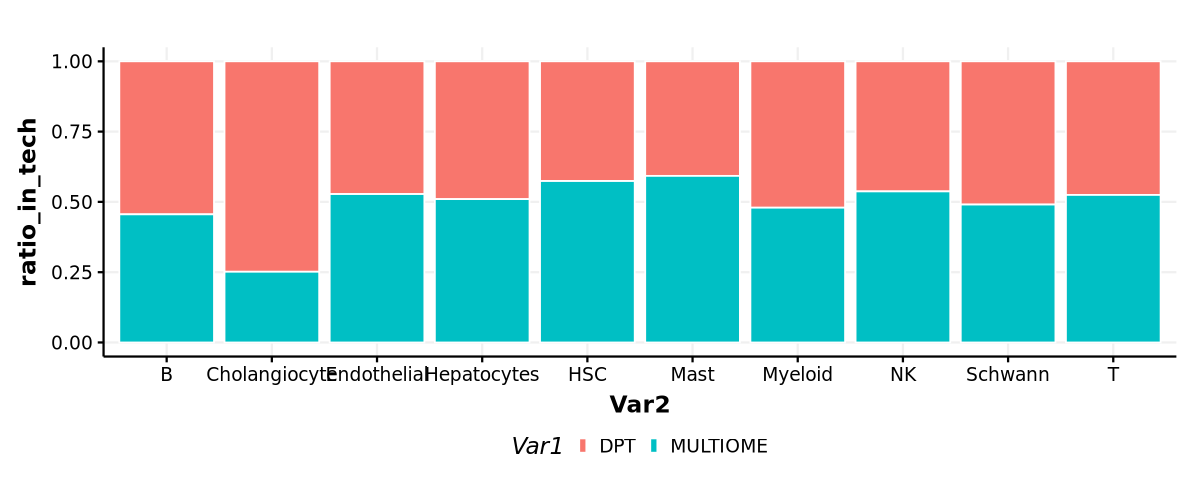

In [98]:
### Add detailed donor info
dmeta <- read.csv("../reference/FNIH_Livers_donorinfo_updated_240906.csv")
obj$DONOR <- obj$Donor
obj@meta.data[colnames(ref), ]$DONOR <- obj@meta.data[colnames(ref),]$donor_demux
obj$DESCRIPTION <- dmeta[match(obj$DONOR, dmeta$Patient.identifier), ]$Description
obj$FIBROSIS <- dmeta[match(obj$DONOR, dmeta$Patient.identifier), ]$Fibrosis.stage..Brunt.Keliner. 

obj$nn2.celltype <- NA
obj@meta.data[colnames(ref), c("nn2.celltype")] <- obj@meta.data[colnames(ref), c("celltype")] ### original
obj@meta.data[colnames(mmg), c("nn2.celltype")] <- obj@meta.data[colnames(mmg), c("predicted.celltype")] ### prediction

options(repr.plot.width = 10, repr.plot.height = 5)

t1 <- DimPlot(obj, reduction = "joint.umap", group.by = 'orig.ident')
t2 <- DimPlot(obj, reduction = "joint.umap", group.by = "nn2.celltype", label = T, repel = T) + NoLegend()
fig1 <- cowplot::plot_grid(t1, t2, rel_widths = c(1.2, 1))

fig1

t1 <- obj@meta.data %>% ggplot(aes(x = predicted.celltype.score)) + geom_histogram(color = "white", bins = 50) + ggtitle("predicted.celltype.score")
t2 <- obj@meta.data %>% ggplot(aes(x = predicted.cellsubtype.score)) + geom_histogram(color = "white", bins = 50) + ggtitle("predicted.cellsubtype.score")
fig2 <- cowplot::plot_grid(t1, t2)

fig2

options(repr.plot.width = 10, repr.plot.height = 4)
table(obj$orig.ident, obj$nn2.celltype) %>%
as.data.frame %>% group_by(Var1) %>% mutate(ratio_in_tech = Freq / sum(Freq)) %>%
ungroup() %>%
ggplot(aes(x = Var2, y = ratio_in_tech, fill = Var1)) + 
geom_col(position = "fill", color = "white") + 
theme_Publication()

In [107]:
qs::qsave(obj, "integration/FNIH_Liver_Multiome_DPT_RNA_int.obj.qs")

### Now add in Hi-C data

In [172]:
qmeta <- gene3c@meta.data %>% filter(predicted.score >= 0.9 & nCount_RNA >= 500 & `cis_1kb+` >= 500)
tmp <- subset(gene3c, cells = rownames(qmeta))
tmp <- AddMetaData(tmp, metadata = qmeta, col.name = colnames(qmeta))
obj1 <- CreateSeuratObject(obj@assays$SCT@counts, meta.data = obj@meta.data)
obj1 <- merge(obj1, tmp) 

obj1@meta.data[colnames(tmp), ]$orig.ident <- "DHC"
obj1@meta.data[colnames(obj), ]$nn2.celltype <- obj$nn2.celltype
obj1@meta.data[colnames(tmp), ]$nn2.celltype <- tmp$predicted.id

obj1$nn2.cellsubtype <- NA
obj1@meta.data[obj1$orig.ident == "MULTIOME", ]$nn2.cellsubtype <- obj1@meta.data[obj1$orig.ident == "MULTIOME", ]$cellsubtype
obj1@meta.data[obj1$orig.ident == "DPT", ]$nn2.cellsubtype <- obj1@meta.data[obj1$orig.ident == "DPT", ]$predicted.cellsubtype

qs::qsave(tmp, "../../92.FNIH_DHC_IGM_241121/05.R/integration/FNIH_DHC_genescore.int.filtered.qs")

In [173]:
### Add UMAP
### Hi-C embedding
eb1 <- tmp@reductions$ref.umap@cell.embeddings %>% 
as.data.frame %>% setNames(c("V1", "V2"))
### RNA embedding
eb2 <- obj@reductions$joint.umap@cell.embeddings %>% 
as.data.frame %>% setNames(c("V1", "V2"))
ebed <- rbind(eb1, eb2)[colnames(obj1), 1:2] %>% setNames(c("UMAP_1", "UMAP2"))

obj1[["joint.umap"]] <- CreateDimReducObject(embeddings = as.matrix(ebed), key = "UMAP_", assay = "RNA")
obj1

qs::qsave(obj1, "../../92.FNIH_DHC_IGM_241121/05.R/integration/All_data.int.qs")

write.table(obj1@meta.data, "../../92.FNIH_DHC_IGM_241121/05.R/integration/All_data.int.txt", 
           sep = "\t", quote = F, row.names = T, col.names = T)
write.csv(obj1@meta.data, "../../92.FNIH_DHC_IGM_241121/05.R/integration/All_data.int.csv", quote = F)

An object of class Seurat 
39549 features across 680462 samples within 2 assays 
Active assay: RNA (36602 features, 0 variable features)
 2 layers present: counts.1, counts.2
 1 other assay present: SCT
 1 dimensional reduction calculated: joint.umap

## Filter cells and write final object

In [183]:
valid1 <- obj1@meta.data[obj1$orig.ident == "MULTIOME",] %>% rownames
valid21 <- obj1@meta.data[obj1$orig.ident == "DPT" & obj1$predicted.celltype.score >= 0.8,] %>% rownames ### for Mast
valid22 <- obj1@meta.data[obj1$orig.ident == "DPT" & obj1$predicted.cellsubtype.score >= 0.8,] %>% rownames
valid3 <- obj1@meta.data[obj1$orig.ident == "DHC" & obj1$Donor != "HL180069",] %>% rownames

obj1$integrated_majortype <- obj1$integrated_subtype <- "0"
obj1@meta.data[c(valid1, valid21, valid3),]$integrated_majortype <- "1"
obj1@meta.data[c(valid1, valid22),]$integrated_subtype <- "1"

In [27]:
options(repr.plot.width = 10, repr.plot.height = 5)
t1 <- obj1@meta.data %>% 
filter(orig.ident == "DPT") %>%
mutate(predicted.celltype = factor(predicted.celltype, levels = corder)) %>%
ggplot(aes(x = predicted.celltype, y = predicted.celltype.score, fill = predicted.celltype)) + 
geom_boxplot(width = 0.5, coef = 2, outlier.shape = NA) +
theme_Publication() + ggtitle("DPT RNA") + scale_fill_manual(values = celltype_colors) + 
theme(axis.text.x = element_text(angle = 45, hjust = 1)) + NoLegend()

t2 <- obj1@meta.data %>% 
filter(orig.ident == "DHC") %>%
mutate(predicted.id = factor(predicted.id, levels = corder)) %>%
ggplot(aes(x = predicted.id, y = predicted.score, fill = predicted.id)) + 
geom_boxplot(width = 0.5, coef = 2, outlier.shape = NA) +
theme_Publication() + ggtitle("DHC") + scale_fill_manual(values = celltype_colors) +
theme(axis.text.x = element_text(angle = 45, hjust = 1)) + NoLegend()

tmp <- obj1@meta.data %>% filter(orig.ident == "DPT")
ckorder <- tmp %>% 
mutate(predicted.celltype = factor(predicted.celltype, levels = corder)) %>%
arrange(predicted.celltype) %>% dplyr::select(predicted.cellsubtype) %>% distinct %>% unlist

t3 <- tmp %>%
mutate(predicted.cellsubtype = factor(predicted.cellsubtype, levels = ckorder)) %>%
ggplot(aes(x = predicted.cellsubtype, y = predicted.cellsubtype.score, fill = predicted.cellsubtype)) + 
geom_boxplot(width = 0.5, coef = 2, outlier.shape = NA) +
theme_Publication() + ggtitle("DPT RNA") + scale_fill_manual(values = cellsubtype_colors) + 
theme(axis.text.x = element_text(angle = 45, hjust = 1)) + NoLegend() 


fig1 <- cowplot::plot_grid(t1, t2, t3, nrow = 3)

ggsave(fig1, filename = "plot/FIG_majorcelltype_prediction_score.pdf", dpi = 150, height = 9, width = 8)

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


## Output figures

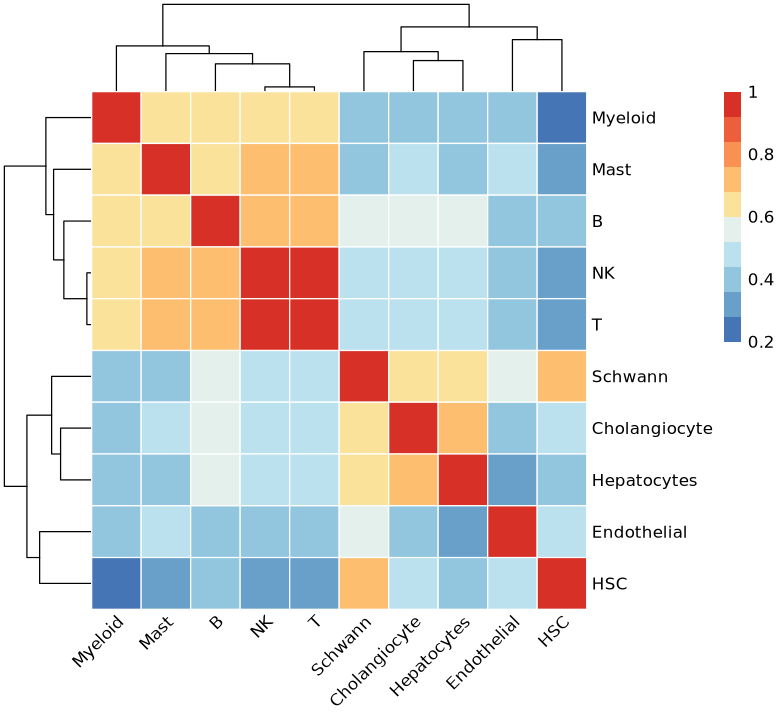

In [196]:
### RNA only
expr <- AggregateExpression(obj, assays = "RNA", group.by = "nn2.celltype", 
                            features = VariableFeatures(ref, assay = "SCT"))

options(repr.plot.width = 6.5, repr.plot.height = 6)
cor(as.matrix(expr$RNA), method = "spearman") %>%
pheatmap(scale = "none", border_color = "white", angle_col = 45, breaks = seq(0.2, 1, 0.08), 
         color = colorRampPalette(rev(brewer.pal(n = 8, name = "RdYlBu")))(10))

SCT assay doesn't leave any cells, so it is removed



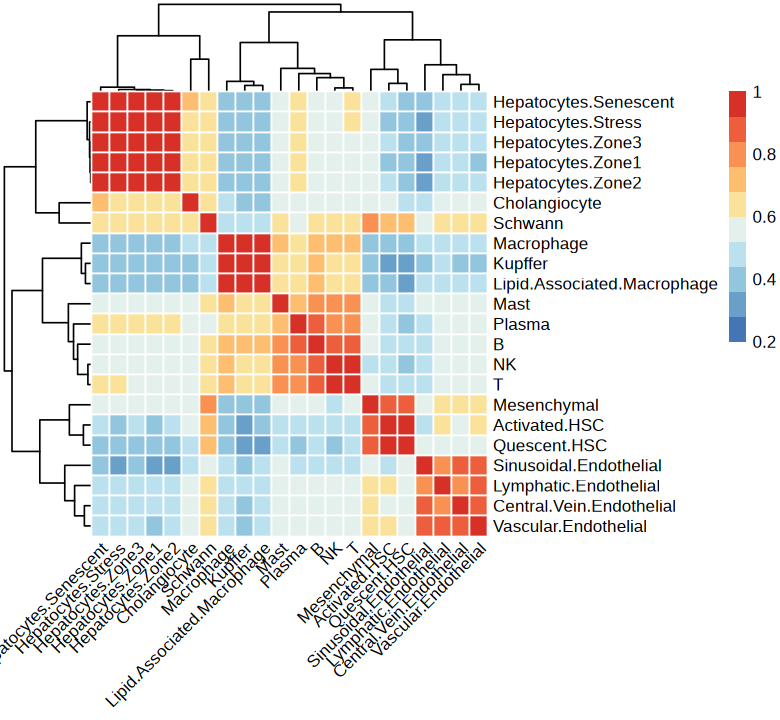

In [54]:
valid <- obj1@meta.data %>%
filter(orig.ident %in% c("DPT", "MULTIOME"), integrated_subtype == 1) %>%
rownames

tmp <- subset(obj1, cells = valid)
expp <- AggregateExpression(tmp, assays = "RNA", group.by = "nn2.cellsubtype",  
                            features = VariableFeatures(ref, assay = "SCT"))

options(repr.plot.width = 6.5, repr.plot.height = 6)
cor(as.matrix(expp$RNA), method = "spearman") %>%
pheatmap(scale = "none", border_color = "white", angle_col = 45, breaks = seq(0.2, 1, 0.08), 
         color = colorRampPalette(rev(brewer.pal(n = 8, name = "RdYlBu")))(10))

In [5]:
obj1 <- qs::qread("../../92.FNIH_DHC_IGM_241121/05.R/integration/All_data.int.qs")
obj1

An object of class Seurat 
39549 features across 680462 samples within 2 assays 
Active assay: RNA (36602 features, 0 variable features)
 2 layers present: counts.1, counts.2
 1 other assay present: SCT
 1 dimensional reduction calculated: joint.umap

In [15]:
obj1@meta.data %>% #filter(integrated_majortype == "1") %>%
select(orig.ident) %>%
table

obj1@meta.data %>% filter(integrated_majortype == "1") %>%
select(orig.ident) %>%
table

orig.ident
     DHC      DPT MULTIOME 
   90450   181834   408178 

orig.ident
     DHC      DPT MULTIOME 
   89891   180679   408178 

In [16]:
tmeta <- obj1@meta.data
tmeta[,c('UMAP_1','UMAP_2')] <- obj1@reductions$joint.umap@cell.embeddings
valid_col1 <- c('orig.ident','nCount_RNA','nFeature_RNA','percent.mt',
                'DONOR', 'DESCRIPTION', 'FIBROSIS',
                'total','mapped','unmapped','duplicate','cis','cis_1kb.','cis_1kb..1','cis_10kb.','trans',
                'integrated_majortype','nn2.celltype','nn2.cellsubtype','integrated_subtype','tech','UMAP_1','UMAP_2')
write.table(tmeta[,valid_col1], "../../92.FNIH_DHC_IGM_241121/05.R/integration/All_data.int.simple.xls", 
            sep = "\t", quote = F, row.names = T, col.names = T)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



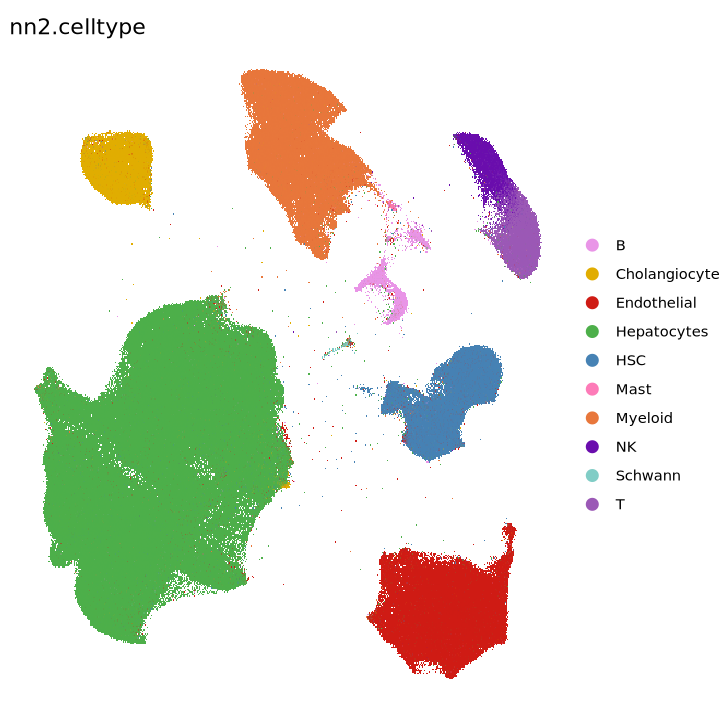

In [188]:
### UMAP of all
valid <- obj1@meta.data[obj1$integrated_majortype == '1',] %>% rownames

options(repr.plot.width = 6, repr.plot.height = 6)
t1 <- DimPlot(obj1, group.by = "nn2.celltype", cols = celltype_colors, label = F, 
              reduction = "joint.umap", cells = valid, raster = T) + ggtitle("") + theme_void() + NoLegend()
t1$layers[[1]]$aes_params$alpha = 0.2 

t2 <- DimPlot(obj1, group.by = "nn2.celltype", cols = celltype_colors, label = F,
              reduction = "joint.umap", cells = valid) + theme_void()

t2
ggsave(t1, filename = "plot/FIG_alldata_umap.png", dpi = 300, height = 6, width = 6)
ggsave(t2, filename = "plot/FIG_alldata_umap.pdf", dpi = 150, height = 6, width = 6)
write.table(t1$data, "plot/FIG_alldata_umap.xls", sep = "\t", quote = F, row.names = T, col.names = T)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



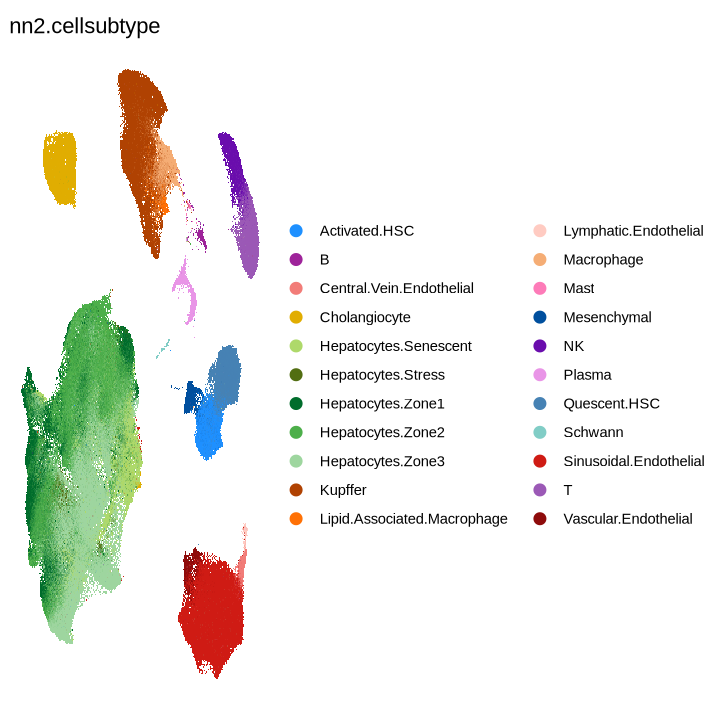

In [11]:
### UMAP of subtypes
valid <- obj1@meta.data[obj1$integrated_subtype == '1',] %>% rownames

options(repr.plot.width = 6, repr.plot.height = 6)
t1 <- DimPlot(obj1, group.by = "nn2.cellsubtype", cols = cellsubtype_colors, label = F, 
              reduction = "joint.umap", cells = valid, raster = T) + ggtitle("") + theme_void() + NoLegend()
t1$layers[[1]]$aes_params$alpha = 0.2 

t2 <- DimPlot(obj1, group.by = "nn2.cellsubtype", cols = cellsubtype_colors, label = F,
              reduction = "joint.umap", cells = valid) + theme_void()

t2

In [193]:
### detailed donor info
obj1@meta.data[obj1$orig.ident == 'DHC',]$DONOR <- obj1@meta.data[obj1$orig.ident == 'DHC',]$Donor
table(is.na(obj1$DONOR))

# dmeta2 <- read.table("../reference/Donor_condition.xls")
obj1$DESCRIPTION <- dmeta2[match(obj1$DONOR, dmeta2$donor_demux), ]$condition


 FALSE 
680462 

In [204]:
obj1$Fibrosis.stage <- obj1$Fibrosis.stage2
obj1@meta.data[obj1$orig.ident != "MULTIOME", ]$Fibrosis.stage <- obj1@meta.data[obj1$orig.ident != "MULTIOME", ]$Fibrosis.stage..Brunt.Keliner.
table(is.na(obj1$Fibrosis.stage))


 FALSE 
680462 

In [205]:
obj1$tech <- "ATAC"
obj1@meta.data[obj1$orig.ident == "DHC",]$tech <- "Hi-C"
obj1@meta.data[obj1$orig.ident == "DPT" & obj1$Target == "H3K27ac",]$tech <- "H3K27ac"
obj1@meta.data[obj1$orig.ident == "DPT" & obj1$Target == "H3K27me3",]$tech <- "H3K27me3"
table(is.na(obj1$tech))


 FALSE 
680462 

In [200]:
gmeta <- obj@meta.data[rownames(obj1@meta.data[obj1$orig.ident != 'DHC' & obj1$integrated_majortype == '1',]),]

tmp_cor <- cor(as.matrix(expr$RNA), method = "spearman")
Z = hclust(as.dist(1-tmp_cor), method = 'complete')

library(ggdendro)
ddo <- as.dendrogram(Z)
data <- dendro_data(ddo, type = "rectangle")

In [21]:
cols1 <- c('#1F78B4', '#FB9A99'); names(cols1) <- c("M", "F")
cols2 <- colorRampPalette(brewer.pal(n = 8, name = "Reds"))(5)[2:5]; names(cols2) <- c("Control", "MASL", "MASH", "MetALD") #e39781
cols3 <- colorRampPalette(brewer.pal(n = 9, name = "YlGn"))(6)[2:6]; names(cols3) <- 0:4
cols4 <- c("#006934", "#2EA7E0", "#956134", "#036EB8"); names(cols4) <- c("Hi-C", "H3K27ac", "H3K27me3","ATAC")

In [231]:
### For plotting
gmeta <- obj1@meta.data[valid,]

t0 <- ggplot(segment(data)) + 
geom_segment(aes(x = x, y = y, xend = xend, yend = yend)) + 
coord_flip() + 
scale_y_reverse(expand = c(0.2, 0)) + 
theme_void()

t1 <- table(gmeta$Gender, gmeta$nn2.celltype) %>%
as.data.frame %>% 
mutate(Var2 = factor(Var2, levels = corder)) %>%
group_by(Var1) %>% mutate(ratio_in_tech = Freq / sum(Freq)) %>%
ungroup() %>%
ggplot(aes(y = Var2, x = ratio_in_tech, fill = Var1)) + 
geom_col(position = "fill", color = "white") + xlab("Gender") + ylab("") +
theme_Publication() + scale_fill_manual(values = cols1)

t2 <- table(gmeta$DESCRIPTION, gmeta$nn2.celltype) %>%
as.data.frame %>% 
mutate(Var2 = factor(Var2, levels = corder)) %>%
mutate(Var1 = factor(Var1, levels = c("Control", "MASL", "MASH", "MetALD"))) %>%
group_by(Var1) %>% mutate(ratio_in_tech = Freq / sum(Freq)) %>%
ungroup() %>%
ggplot(aes(y = Var2, x = ratio_in_tech, fill = Var1)) + 
geom_col(position = "fill", color = "white") + xlab("DESCRIPTION") + ylab("") +
theme_Publication() + scale_fill_manual(values = cols2)

t3 <- table(gmeta$Fibrosis.stage, gmeta$nn2.celltype) %>%
as.data.frame %>% #mutate(Var1 = factor(Var1, levels = c("ATAC", "H3K27ac", "H3K27me3"))) %>%
mutate(Var2 = factor(Var2, levels = corder)) %>%
# group_by(Var1) %>% 
mutate(ratio_in_tech = Freq / sum(Freq)) %>%
# ungroup() %>%
ggplot(aes(y = Var2, x = ratio_in_tech, fill = Var1)) + 
geom_col(position = "fill", color = "white") + xlab("Fibrosis") + ylab("") +
theme_Publication() + scale_fill_manual(values = cols3)

t4 <- table(gmeta$tech, gmeta$nn2.celltype) %>%
as.data.frame %>% mutate(Var1 = factor(Var1, levels = c("ATAC", "Hi-C", "H3K27ac", "H3K27me3"))) %>%
mutate(Var2 = factor(Var2, levels = corder)) %>%
# group_by(Var1) %>% 
mutate(ratio_in_tech = Freq / sum(Freq)) %>%
# ungroup() %>%
ggplot(aes(y = Var2, x = ratio_in_tech, fill = Var1)) + 
geom_col(position = "fill", color = "white") + xlab("Modalities") + ylab("") +
theme_Publication() + scale_fill_manual(values = cols4)

t1 <- cowplot::plot_grid(t0, t1, t2, t3, t4, ncol = 5, rel_widths = c(0.6,1,1,1,1))
ggsave(t1, filename = "plot/FIG_alldata_barplot_condition.pdf", dpi = 300, height = 5, width = 12)

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


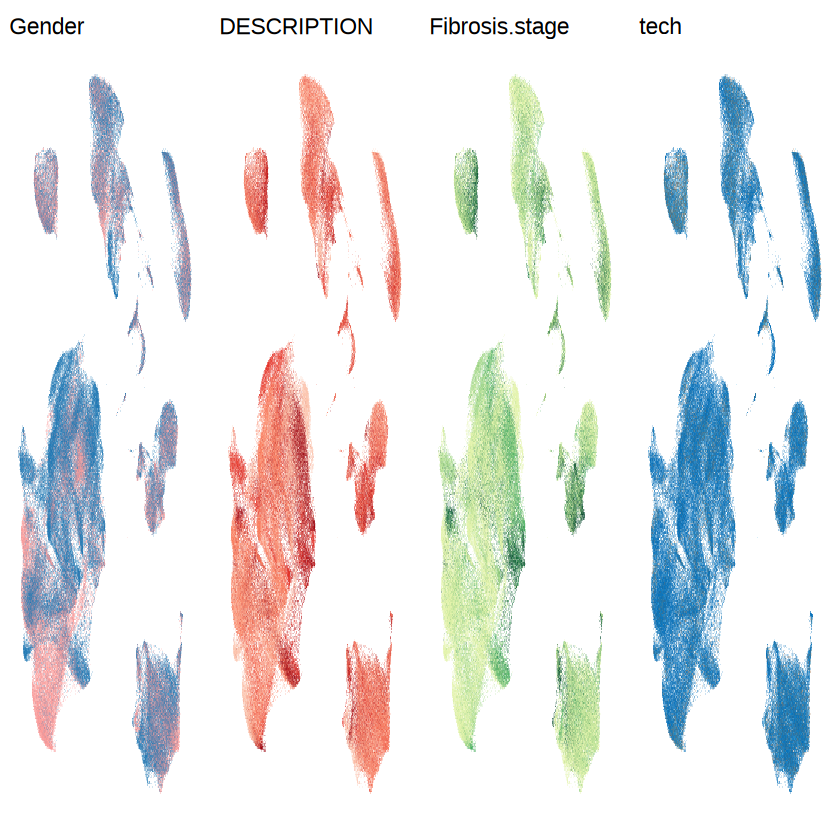

In [23]:
### UMAP
t1 <- DimPlot(obj1, reduction = "joint.umap", group.by = "Gender", cols = cols1, label = F, 
              cells = valid, raster = T) + theme_void() + NoLegend()
t1$layers[[1]]$aes_params$alpha = 0.2 
t2 <- DimPlot(obj1, reduction = "joint.umap", group.by = "DESCRIPTION", cols = cols2, label = F, 
              cells = valid, raster = T) + theme_void() + NoLegend()
t2$layers[[1]]$aes_params$alpha = 0.2
t3 <- DimPlot(obj1, reduction = "joint.umap", group.by = "Fibrosis.stage", cols = cols3, label = F, 
              cells = valid, raster = T) + theme_void() + NoLegend()
t3$layers[[1]]$aes_params$alpha = 0.2 
t4 <- DimPlot(obj1, reduction = "joint.umap", group.by = "tech", cols = cols4, label = F, 
              cells = valid, raster = T) + theme_void() + NoLegend()
t4$layers[[1]]$aes_params$alpha = 0.2 

fig1 <- cowplot::plot_grid(t1, t2, t3, t4, ncol = 4)
fig1

ggsave(fig1, filename = "plot/FIG_alldata_umap_condition.png", dpi = 300, height = 4, width = 16)

In [217]:
donor_order <- gmeta[,c("Age", "DONOR", "DESCRIPTION")] %>%
distinct %>%
mutate(DESCRIPTION = factor(DESCRIPTION, levels = c("Control", "MASL", "MASH", "MetALD"))) %>%
arrange(DESCRIPTION, Age) %>%
select(DONOR) %>% unlist

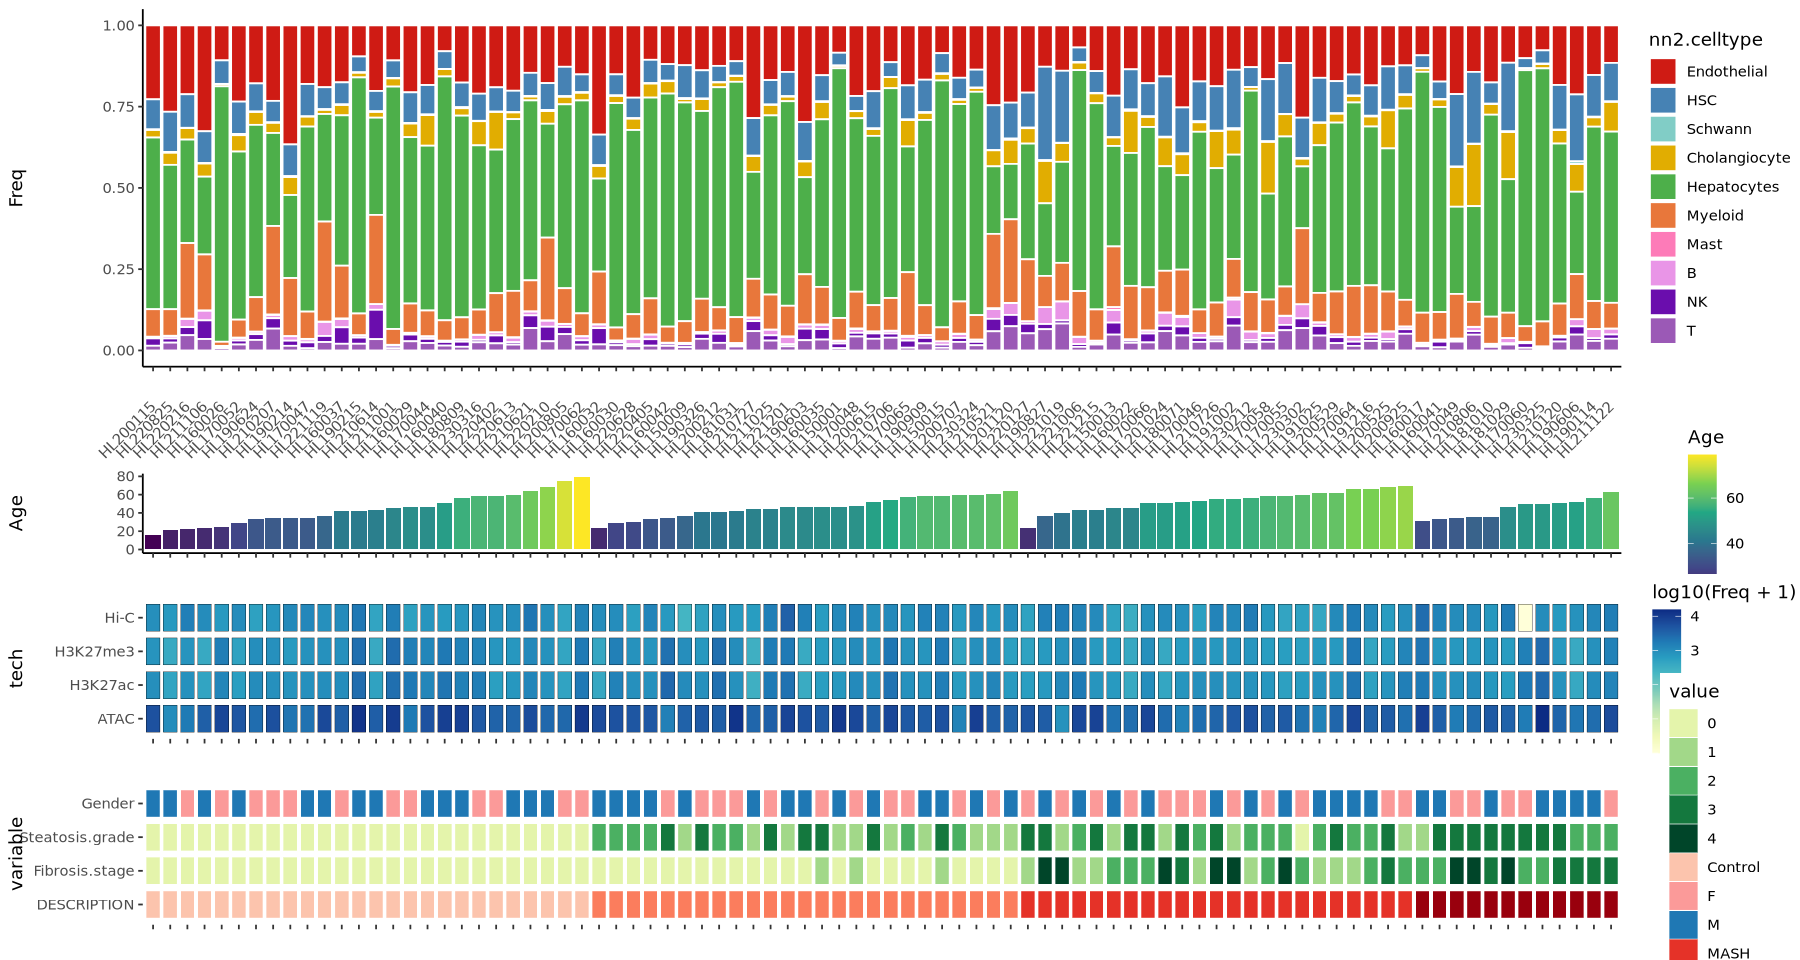

In [236]:
### Donor info and techniques summary, version 2
t1 <- gmeta[, c("DONOR", "nn2.celltype")] %>%
table %>% as.data.frame %>%
mutate(nn2.celltype = factor(nn2.celltype, levels = corder)) %>%
mutate(DONOR = factor(DONOR, levels = donor_order)) %>%
arrange(DONOR) %>%
ggplot(aes(x = DONOR, y = Freq, fill = nn2.celltype)) + 
geom_col(position = "fill", color = "white") + 
theme_classic() + xlab("") + 
theme(axis.text.x = element_text(angle = 45, vjust = 0.5, hjust=1)) + 
scale_fill_manual(values = celltype_colors)

t2 <- gmeta[,c("DONOR", "Age")] %>% distinct %>%
mutate(DONOR = factor(DONOR, levels = donor_order)) %>%
arrange(DONOR) %>%
ggplot(aes(x = DONOR, y = Age, fill = Age)) + 
geom_col() + 
theme_classic() + xlab("") + 
theme(axis.text.x = element_blank()) + 
scale_fill_viridis_c()

t3 <- gmeta[,c("DONOR", "tech")] %>%
table %>% as.data.frame %>%
mutate(DONOR = factor(DONOR, levels = donor_order)) %>%
arrange(DONOR) %>%
ggplot(aes(x = DONOR, y = tech, fill = log10(Freq + 1))) + 
geom_tile(color = "black", width=0.8, height=0.8) + 
theme_classic() + xlab("") + 
theme(axis.text.x = element_blank(), axis.line.x = element_blank(), axis.line.y = element_blank()) + 
scale_fill_gradientn(colors = colorRampPalette(brewer.pal(n = 8, name = "YlGnBu"))(10))

t4 <- gmeta[,c("DONOR", "Gender", "DESCRIPTION", "Steatosis.grade", "Fibrosis.stage")] %>% distinct %>%
reshape2::melt(id.vars = "DONOR") %>%
mutate(DONOR = factor(DONOR, levels = donor_order)) %>% arrange(DONOR) %>%
mutate(variable = factor(variable, levels = c("DESCRIPTION", "Fibrosis.stage", "Steatosis.grade", "Gender"))) %>%
ggplot(aes(x = DONOR, y = variable, fill = value)) + 
geom_tile(color = "white", width=0.8, height=0.8) + 
theme_classic() + xlab("") + 
theme(axis.text.x = element_blank(), axis.line.x = element_blank(), axis.line.y = element_blank()) + 
scale_fill_manual(values = c(cols1, cols2, cols3))

options(repr.plot.width = 15, repr.plot.height = 8)
fig1 <- cowplot::plot_grid(t1, t2, t3, t4, rel_heights = c(1.5, 0.4, 0.6, 0.6), ncol = 1, align = 'v')
fig1

ggsave(fig1, filename = "plot/FIG_alldata_donor_info_v2.pdf", dpi = 150, height = 8, width = 15)

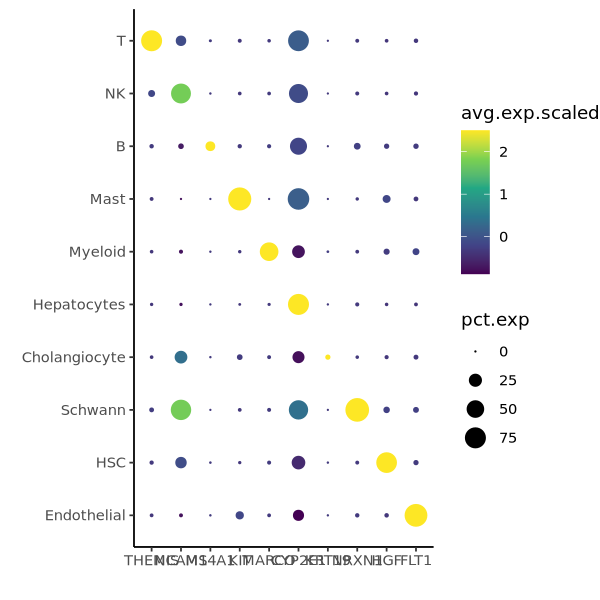

In [631]:
qfeatures <- c("THEMIS", "NCAM1", "MS4A1", "KIT", "MARCO", "CYP2E1", "KRT19", "NRXN1", "HGF", "FLT1")
t1 <- DotPlot(obj, qfeatures, group.by = "nn2.celltype")
t1 <- t1$data %>%
mutate(features.plot = factor(features.plot, levels = qfeatures)) %>%
mutate(id = factor(id, levels = corder)) %>%
ggplot(aes(x = features.plot, y = id)) + 
geom_point(aes(color = avg.exp.scaled, size = pct.exp)) + 
theme_classic() + scale_size(range = c(0, 6)) + xlab("") + ylab("") +
scale_color_viridis_c()

options(repr.plot.width = 5, repr.plot.height = 5)
t1

ggsave(t1, filename = "plot/FIG_celltype_markerGene_exp.pdf", dpi = 300, height = 5, width = 5)

## UMAP by tech and the other modalities

In [5]:
mmg <- qs::qread("FNIH_DPT_clustering/FNIH_Liver_pool_DPT_SNG_SoupX_reference_mapping_filtered.qs")
ref <- readRDS("../reference/Final_fNIH_Liver_10X_Multiome_object.rds")
ref
mmg

Loading required package: Signac



An object of class Seurat 
548484 features across 408178 samples within 3 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: SCT, Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

An object of class Seurat 
70217 features across 181834 samples within 2 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 5 dimensional reductions calculated: pca, harmony, umap, k27ac_umap, k27me3_umap

In [272]:
cell1 <- obj1@meta.data[obj1$orig.ident == "MULTIOME" & obj1$integrated_majortype == "1", ] %>% rownames
cell2 <- obj1@meta.data[obj1$orig.ident == "DPT" & obj1$integrated_majortype == "1" & obj1$Target == "H3K27ac", ] %>% rownames
cell3 <- obj1@meta.data[obj1$orig.ident == "DPT" & obj1$integrated_majortype == "1" & obj1$Target == "H3K27me3", ] %>% rownames
cell4 <- obj1@meta.data[obj1$orig.ident == "DHC" & obj1$integrated_majortype == "1", ] %>% rownames

In [315]:
length(cell1); length(cell2); length(cell3); length(cell4)

[1] 408178

[1] 94125

[1] 86554

[1] 89891

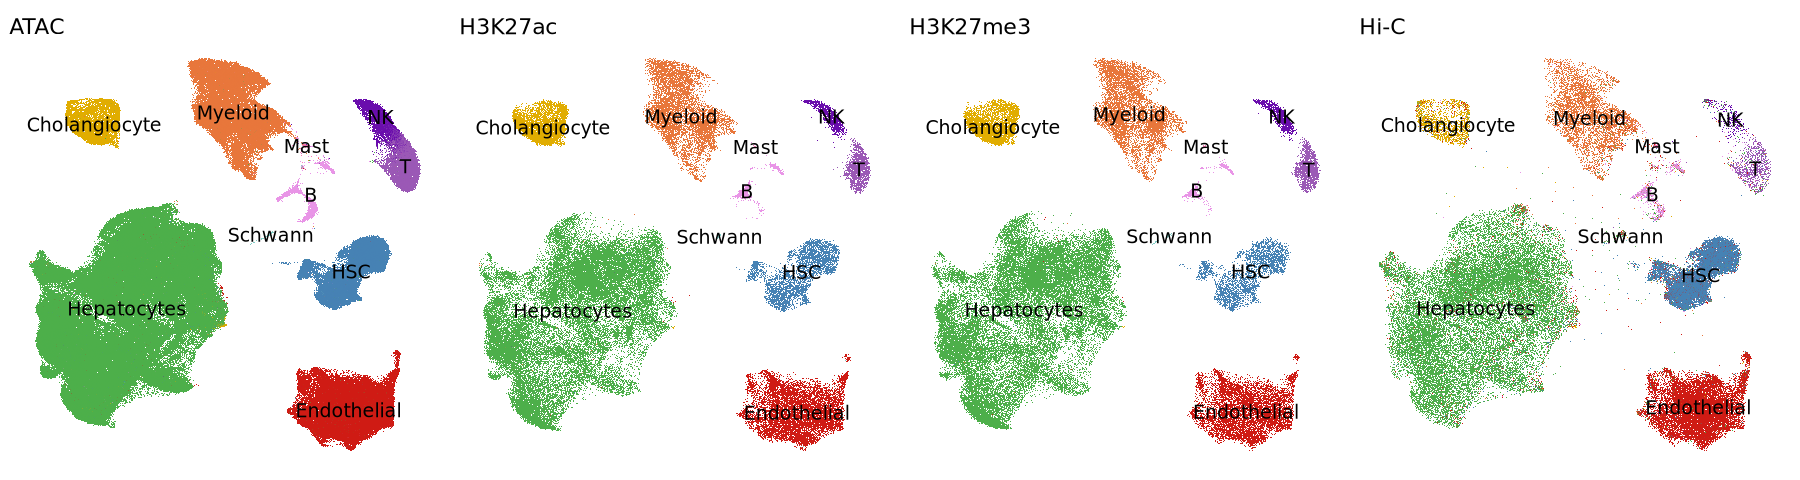

In [310]:
t1 <- DimPlot(obj1, group.by = "nn2.celltype", cols = celltype_colors, label = T, 
              reduction = "joint.umap", cells = cell1, raster = T) + ggtitle("ATAC") + theme_void() + NoLegend()
t2 <- DimPlot(obj1, group.by = "nn2.celltype", cols = celltype_colors, label = T, 
              reduction = "joint.umap", cells = cell2, raster = T) + ggtitle("H3K27ac") + theme_void() + NoLegend()
t3 <- DimPlot(obj1, group.by = "nn2.celltype", cols = celltype_colors, label = T, 
              reduction = "joint.umap", cells = cell3, raster = T) + ggtitle("H3K27me3") + theme_void() + NoLegend()
t4 <- DimPlot(obj1, group.by = "nn2.celltype", cols = celltype_colors, label = T, 
              reduction = "joint.umap", cells = cell4, raster = T) + ggtitle("Hi-C") + theme_void() + NoLegend()

options(repr.plot.width = 15, repr.plot.height = 4)
cowplot::plot_grid(t1, t2, t3, t4, ncol = 4)

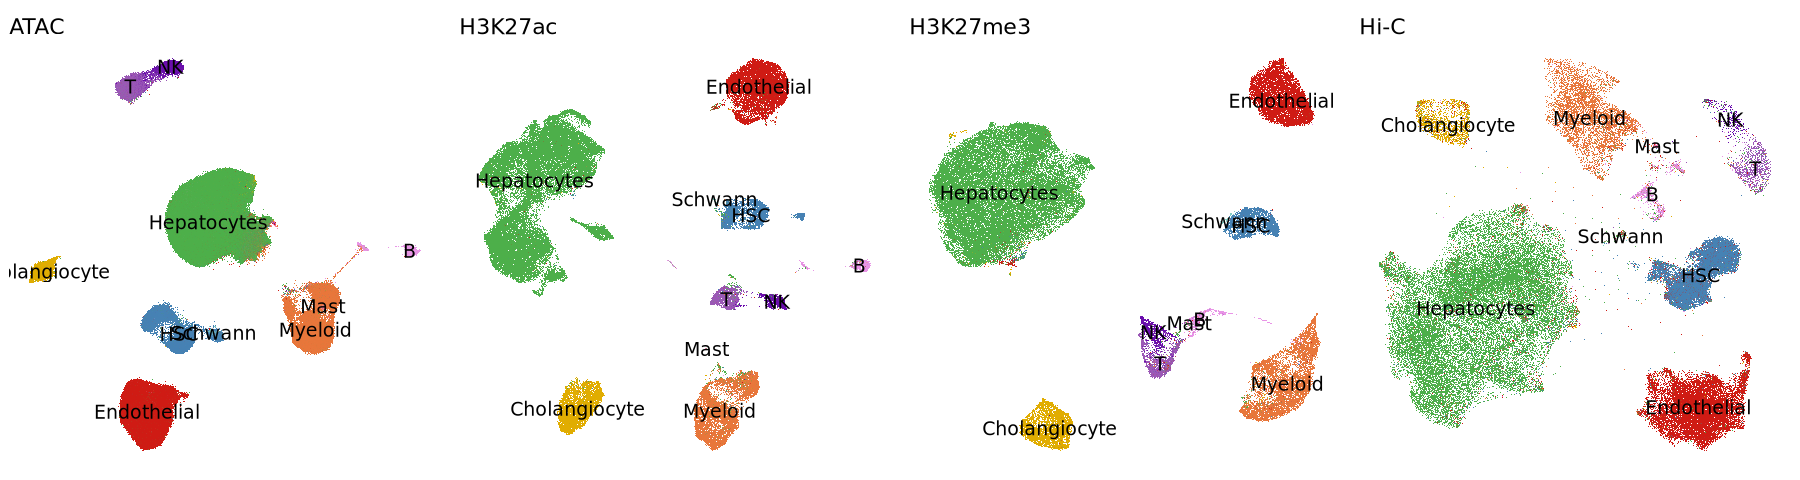

In [306]:
t1 <- DimPlot(ref, group.by = "celltype", cols = celltype_colors, label = T, 
              reduction = "umap.atac", cells = cell1, raster = T) + ggtitle("ATAC") + theme_void() + NoLegend()
t2 <- DimPlot(mmg, group.by = "predicted.celltype", cols = celltype_colors, label = T, 
              reduction = "k27ac_umap", cells = cell2, raster = T) + ggtitle("H3K27ac") + theme_void() + NoLegend()
t3 <- DimPlot(mmg, group.by = "predicted.celltype", cols = celltype_colors, label = T, 
              reduction = "k27me3_umap", cells = cell3, raster = T) + ggtitle("H3K27me3") + theme_void() + NoLegend()
t4 <- DimPlot(obj1, group.by = "nn2.celltype", cols = celltype_colors, label = T, 
              reduction = "joint.umap", cells = cell4, raster = T) + ggtitle("Hi-C") + theme_void() + NoLegend()

options(repr.plot.width = 15, repr.plot.height = 4)
cowplot::plot_grid(t1, t2, t3, t4, ncol = 4)

## Modalities QC results

In [343]:
t1 <- gmeta[cell1, c('nCount_RNA_raw', 'nFeature_RNA_raw', 'atac_fragments', 'nCount_Peaks_Full')] %>%
setNames(c("nCount_RNA", "nFeature_RNA", "nCount_DNA", "nCount_Peaks")) %>%
mutate(FRIP = nCount_Peaks/nCount_DNA) %>%
reshape2::melt() %>%
mutate(modality = "Multiome")

### read Paired-Tag info...
stat <- list()
for (f in list.files("valid_cells/", pattern = '.*PF_cells.txt')){
    stat[[f]] <- read.table(paste0("valid_cells/", f))
}
stat <- do.call(rbind, stat)
rownames(stat) <- paste0(stat$V7, ":", stat$V1)

gmeta$nCount_histone <- gmeta$nCount_histone_peaks <- NA
gmeta[cell2,]$nCount_histone <- stat[gmeta[cell2,]$dna_bc,]$V3
gmeta[cell2,]$nCount_histone_peaks <- stat[gmeta[cell2,]$dna_bc,]$V5
gmeta[cell3,]$nCount_histone <- stat[gmeta[cell3,]$dna_bc,]$V3
gmeta[cell3,]$nCount_histone_peaks <- stat[gmeta[cell3,]$dna_bc,]$V5

t2 <- gmeta[cell2, c('nCount_RNA', 'nFeature_RNA', 'nCount_histone', 'nCount_histone_peaks')] %>%
setNames(c("nCount_RNA", "nFeature_RNA", "nCount_DNA", "nCount_Peaks")) %>%
mutate(FRIP = nCount_Peaks/nCount_DNA) %>%
reshape2::melt() %>%
mutate(modality = "H3K27ac")

t3 <- gmeta[cell3, c('nCount_RNA', 'nFeature_RNA', 'nCount_histone', 'nCount_histone_peaks')] %>%
setNames(c("nCount_RNA", "nFeature_RNA", "nCount_DNA", "nCount_Peaks")) %>%
mutate(FRIP = nCount_Peaks/nCount_DNA) %>%
reshape2::melt() %>%
mutate(modality = "H3K27me3")

t4 <- gmeta[cell4, c("mapped", "cis_1kb..1", "trans")] %>%
setNames(c("Total", "Cis_long", "Trnas")) %>%
reshape2::melt() %>%
mutate(modality = "Hi-C")

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



Warning message:
“Removed 5681 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 5681 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5681 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Removed 5681 rows containing non-finite outside the scale range (`stat_boxplot()`).”


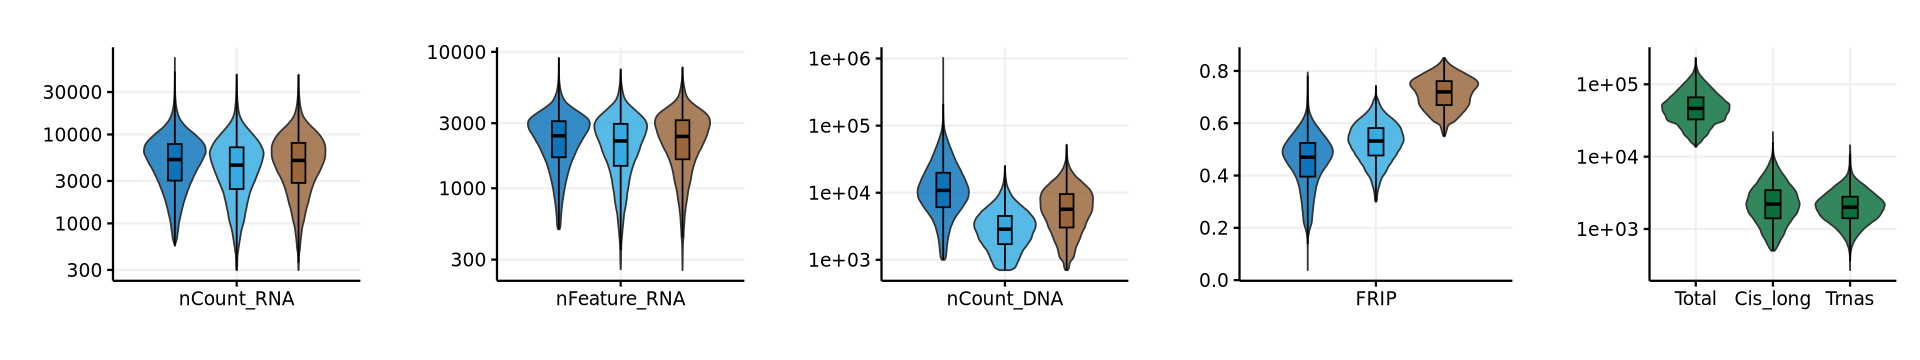

In [366]:
fig11 <- do.call(rbind, list(t1, t2, t3)) %>%
filter(variable %in% c("nCount_RNA")) %>%
mutate(modality = factor(modality, levels = c("Multiome", "H3K27ac", "H3K27me3"))) %>%
ggplot(aes(x = variable, y = value, fill = modality)) + 
geom_violin(alpha = 0.8) + 
geom_boxplot(width = 0.2, color = "black", alpha=0.8, 
             coef = 2, outlier.shape = NA, 
             position = position_dodge(width = 0.9)) + 
scale_y_log10() + 
theme_Publication() + xlab("") + ylab("") +
scale_fill_manual(values = c("#036EB8", "#2EA7E0", "#956134")) + NoLegend()

fig12 <- do.call(rbind, list(t1, t2, t3)) %>%
filter(variable %in% c("nFeature_RNA")) %>%
mutate(modality = factor(modality, levels = c("Multiome", "H3K27ac", "H3K27me3"))) %>%
ggplot(aes(x = variable, y = value, fill = modality)) + 
geom_violin(alpha = 0.8) + 
geom_boxplot(width = 0.2, color = "black", alpha=0.8, 
             coef = 2, outlier.shape = NA, 
             position = position_dodge(width = 0.9)) + 
scale_y_log10() + 
theme_Publication() + xlab("") + ylab("") +
scale_fill_manual(values = c("#036EB8", "#2EA7E0", "#956134")) + NoLegend()

fig2 <- do.call(rbind, list(t1, t2, t3)) %>%
filter(variable %in% c("nCount_DNA")) %>%
mutate(modality = factor(modality, levels = c("Multiome", "H3K27ac", "H3K27me3"))) %>%
ggplot(aes(x = variable, y = value, fill = modality)) + 
geom_violin(alpha = 0.8) + 
geom_boxplot(width = 0.2, color = "black", alpha=0.8, 
             coef = 2, outlier.shape = NA, 
             position = position_dodge(width = 0.9)) + 
scale_y_log10() + 
theme_Publication() + xlab("") + ylab("") +
scale_fill_manual(values = c("#036EB8", "#2EA7E0", "#956134")) + NoLegend()

fig3 <- do.call(rbind, list(t1, t2, t3)) %>%
filter(variable %in% c("FRIP")) %>%
mutate(modality = factor(modality, levels = c("Multiome", "H3K27ac", "H3K27me3"))) %>%
ggplot(aes(x = variable, y = value, fill = modality)) + 
geom_violin(alpha = 0.8) + 
geom_boxplot(width = 0.2, color = "black", alpha=0.8, 
             coef = 2, outlier.shape = NA, 
             position = position_dodge(width = 0.9)) + 
theme_Publication() + xlab("") + ylab("") +
scale_fill_manual(values = c("#036EB8", "#2EA7E0", "#956134")) + NoLegend()

fig4 <- t4 %>%
filter(variable %in% c("Total", "Cis_long", "Trnas")) %>%
ggplot(aes(x = variable, y = value, fill = modality)) + 
geom_violin(alpha = 0.8) + 
geom_boxplot(width = 0.2, color = "black", alpha=0.8, 
             coef = 2, outlier.shape = NA, 
             position = position_dodge(width = 0.9)) + 
scale_y_log10() + 
theme_Publication() + xlab("") + ylab("") +
scale_fill_manual(values = c("#006934")) + NoLegend()

options(repr.plot.width = 16, repr.plot.height = 3)
fig1 <- cowplot::plot_grid(fig11, fig12, fig2, fig3, fig4, ncol = 5, align = 'h')
fig1
ggsave(fig1, filename = "plot/FIG_alldata_QC_by_modality.pdf", dpi = 300, height = 3, width = 15)

## Cell type proportion

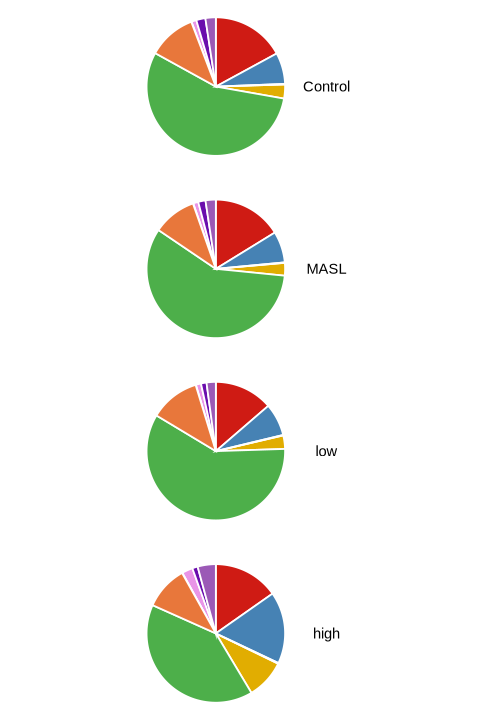

In [28]:
t1 <- obj1@meta.data %>% 
filter(integrated_majortype == 1) %>%
mutate(FIBROSIS_class = ifelse(Fibrosis.stage > 2, "high", "low")) %>%
mutate(DESCRIPTION2 = ifelse(DESCRIPTION %in% c("MASH", "MetALD"), FIBROSIS_class, DESCRIPTION)) %>%
select(c(nn2.celltype, DESCRIPTION2)) %>%
table %>% as.data.frame %>%
mutate(DESCRIPTION2 = factor(DESCRIPTION2, levels = c("Control", "MASL", "low", "high"))) %>%
mutate(nn2.celltype = factor(nn2.celltype, levels = corder)) %>%
ggplot(aes(x = "", y = Freq, fill = nn2.celltype)) + 
geom_bar(stat = "identity", position = position_fill(), color = "white") +
coord_polar(theta = "y") + theme_void() + 
facet_grid(facets=DESCRIPTION2 ~ .) + 
scale_fill_manual(values = celltype_colors) + 
NoLegend()

t1
ggsave(t1, filename = "plot/FIG_celltype_prop_by_disease_fibrosis_class.pdf", dpi = 300, height = 6, width = 5)

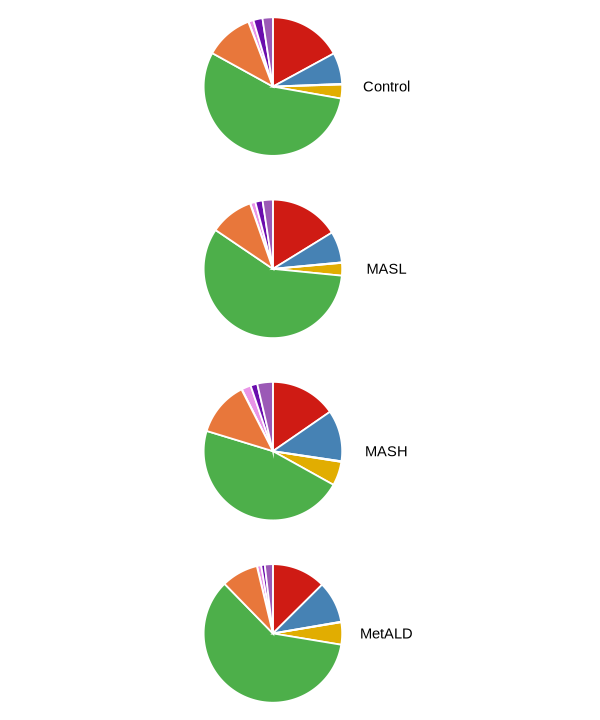

In [44]:
options(repr.plot.width = 5, repr.plot.height = 6)
t1 <- obj1@meta.data %>%
filter(integrated_majortype == 1) %>%
select(c(nn2.celltype, DESCRIPTION)) %>%
table %>% as.data.frame %>%
mutate(DESCRIPTION = factor(DESCRIPTION, levels = c("Control", "MASL", "MASH", "MetALD"))) %>%
mutate(nn2.celltype = factor(nn2.celltype, levels = corder)) %>%
ggplot(aes(x = "", y = Freq, fill = nn2.celltype)) + 
geom_bar(stat = "identity", position = position_fill(), color = "white") +
coord_polar(theta = "y") + theme_void() + 
facet_grid(facets=DESCRIPTION ~ .) + 
scale_fill_manual(values = celltype_colors) + 
NoLegend()

t1
ggsave(t1, filename = "plot/FIG_celltype_prop_by_disease.pdf", dpi = 300, height = 6, width = 5)

### Check TSSe by modalities by cell types

Using sample as id variables



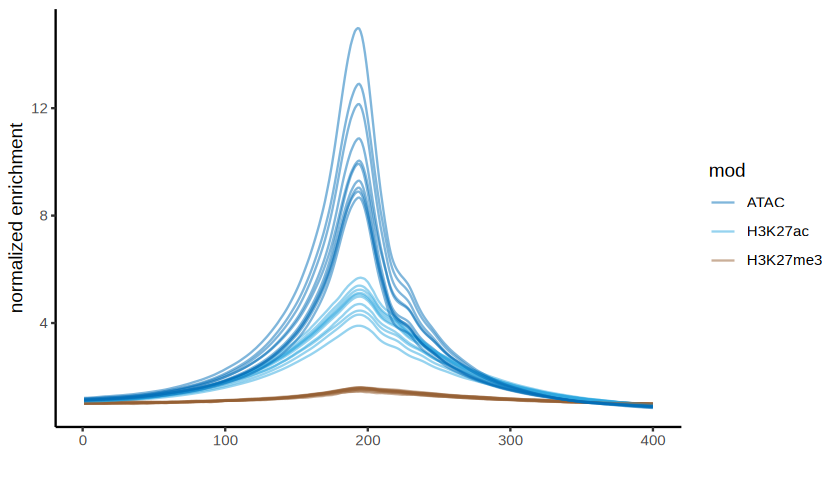

In [37]:
enrichm <- read.csv("../06.bw/FNIH_ATAC_DPT_celltype_TSSe_profile.txt", sep = "\t", skip = 1, header = T, row.names = 1)
enrichm$X <- NULL
bdg <- enrichm[,c(1:3, 397:400)] %>% rowMeans
tmp <- (enrichm[,1:400]/bdg) %>% as.data.frame %>%
tibble::rownames_to_column('sample') %>%
reshape2::melt() %>%
mutate(variable = as.integer(gsub("X", "", variable))) 

t1 <- tmp %>% 
mutate(mod = ifelse(stringr::str_detect(sample, "_H3K27ac.sam"), "H3K27ac", "ATAC")) %>%
mutate(mod = ifelse(stringr::str_detect(sample, "_H3K27me3.sam"), "H3K27me3", mod)) %>%
filter(mod != "NA") %>%
ggplot(aes(x = variable, y = value, color = mod, group = sample)) + 
geom_line(alpha = 0.5, linewidth = 0.5) + 
theme_classic() + xlab("") + ylab("normalized enrichment") + 
scale_color_manual(values = c("#036EB8", "#2EA7E0", "#956134"))

options(repr.plot.width = 7, repr.plot.height = 4)
t1

ggsave(t1, filename = "plot/FIG_ATAC_ac_me3_lib_normTSSe.pdf", dpi = 300, height = 4, width = 7)